# 🔍 Disease Detection Model Training

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import numpy as np
import os
import json
from PIL import Image
print('Libraries loaded!')

Libraries loaded!


In [2]:
pv_dir = '../datasets/PlantVillage'
classes = sorted([d for d in os.listdir(pv_dir) if os.path.isdir(os.path.join(pv_dir, d))])
class_mapping = {str(i): cls for i, cls in enumerate(classes)}
os.makedirs('../../ml_models', exist_ok=True)
with open('../../ml_models/disease_classes.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

X_img, y_img = [], []
for idx, cls in enumerate(classes):
    cls_dir = os.path.join(pv_dir, cls)
    img_names = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:100]
    for name in img_names:
        try:
            img_path = os.path.join(cls_dir, name)
            img = Image.open(img_path).resize((224, 224))
            img_arr = np.array(img) / 255.0
            if img_arr.shape == (224, 224, 3):
                X_img.append(img_arr)
                y_img.append(idx)
        except Exception:
            pass

X_img = np.array(X_img)
y_img = np.array(y_img)
y_img_cat = tf.keras.utils.to_categorical(y_img, num_classes=len(classes))
print(f'Loaded {len(X_img)} images across {len(classes)} classes.')

Loaded 1000 images across 10 classes.


In [3]:
from sklearn.model_selection import train_test_split

# Initialize base MobileNetV2 with avg pooling
base_features_extractor = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet', pooling='avg')
base_features_extractor.trainable = False

print("Pre-extracting features with MobileNetV2...")
X_features = base_features_extractor.predict(X_img, batch_size=32)

X_train_f, X_test_f, y_train, y_test = train_test_split(X_features, y_img_cat, test_size=0.2, random_state=42, stratify=y_img)

# Define and train head
head = models.Sequential([
    layers.Input(shape=(1280,)),
    layers.Dropout(0.2),
    layers.Dense(len(classes), activation='softmax')
])
head.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = head.fit(X_train_f, y_train, epochs=15, batch_size=16, validation_data=(X_test_f, y_test), verbose=1)

# Assemble end-to-end model for saving
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

cnn_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(classes), activation='softmax')
])

# Copy weights
dense_layer_head = [l for l in head.layers if isinstance(l, layers.Dense)][0]
dense_layer_final = [l for l in cnn_model.layers if isinstance(l, layers.Dense)][0]
dense_layer_final.set_weights(dense_layer_head.get_weights())
print('CNN model assembled!')

Pre-extracting features with MobileNetV2...


 1/32 ━━━━━━━━━━━━━━━━━━━━ 1:47 3s/step

 2/32 ━━━━━━━━━━━━━━━━━━━━ 12s 431ms/step

 3/32 ━━━━━━━━━━━━━━━━━━━━ 12s 434ms/step

 4/32 ━━━━━━━━━━━━━━━━━━━━ 12s 438ms/step

...

 1/50 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8750 - loss: 0.4515

24/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9035 - loss: 0.4515 

47/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8993 - loss: 0.4488

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8813 - loss: 0.4435 - val_accuracy: 0.9750 - val_loss: 0.3643


CNN model assembled!


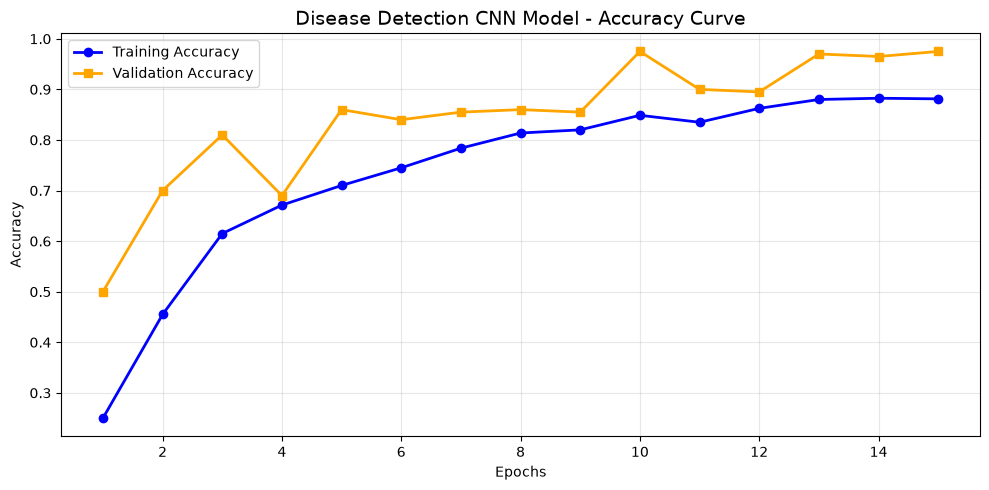

DISEASE DETECTION EVALUATION CURVE
Final Training Accuracy:   88.13%
Final Validation Accuracy: 97.50%


In [4]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_list = list(range(1, len(train_acc) + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs_list, train_acc, label='Training Accuracy', color='blue', marker='o', lw=2)
plt.plot(epochs_list, val_acc, label='Validation Accuracy', color='orange', marker='s', lw=2)
plt.title('Disease Detection CNN Model - Accuracy Curve', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('disease_training_curves.png', dpi=150)
plt.show()

print("="*60)
print("DISEASE DETECTION EVALUATION CURVE")
print("="*60)
print(f"Final Training Accuracy:   {train_acc[-1]*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

In [5]:
cnn_model.save('../../ml_models/disease_detection.h5')
print('Saved CNN disease detection model!')

Saved CNN disease detection model!
